# Técnicas de Muestreo

#### Ana Maria Arcila

#### Instituto de física Universidad de Antioquia

### Resumen

Este informe presenta los resultados obtenidos en un análisis de la equiprobabilidad de las configuraciones de un sistema de discos rígidos en una caja bidimensional. Esto se llevó a cabo con el análisis de tres técnicas de muestreo: Monte Carlo directo, cadenas de Markov y dinámica molecular basada en eventos. Se hicieron simulaciones que nos permiten observar las probabilidades de distintas configuraciones. Los resultados muestran que claramente se cumple el principio de equiprobabilidad. 

<b> Palabras clave: Monte Carlo, cadenas de Markov, muestreo, equiprobabilidad.</b>

### Introducción

La equiprobabilidad es un principio fundamental en la física estadística. Este dice que, en un sistema aislado, todos los sucesos en este sistema tienen la misma probabilidad de ocurrir. En la física estasística esto lo podemos ver con respecto a las configuraciones del sistema, las cuales nos indican las posiciones de las partículas en un sólido, fluído o gas.

En este trabajo, se estudia un sistema de discos rígidos en una caja bidimensional, usando varias técnicas de muestreo. Estas técnicas tienen el objetivo de obtener distintas configuraciones de la manera más eficiente posible, para así poder simular la evolución de sistemas físicos. Vamos a tener en cuenta un gas no ideal, pues las partículas tratadas tienen radios y colisionan entre ellas. Vamos a ver esto cómo afecta a la equiprobabildad del sistema.

El objetivo de este trabajo es implementar y comparar estas técnicas de muestreo, verificando si estas técnicas modelan apropiadamente o violan el principio de equiprobabilidad.

### Marco Teórico

#### Muestreo directo

También llamado muestreo de Monte Carlo, es una técnica que genera muestras aleatorias para obtener la probabilidad de ocurrencia de algún resultado [1].

Funciona al generar aleatoriamente un set de números aleatorios en un rango dado para recalcular los resultados una y otra vez. En este caso, se generaron configuraciones de los discos dentro de la caja y se verificó si estas respetaban las restricciones geométricas y físicas del sistema [2].

#### Cadenas de Markov

También relacionado al modelo Monte Carlo, es un proceso que simula el movimiento de una partícula a lo largo del tiempo. Esto es debido a que genera una coordenada de la partícula dependiendo únicamente de su estado inmediatamente anterior. Esto genera un comportamiento aleatorio en donde se puede ver una trayectoria, lo que nos permite una exploración más detallada del espacio de fases [3].

#### Muestreo basado en eventos

Es un modelo que se basa en la idea de que, en un instate de tiempo, se lleva a cabo máximo una colisión de duraciín infinitesimal. Le da un enfoque a los momentos en los que ocurre un evento o, en otras palabras, una colisión ya sea con las paredes o con otra partícula y en el intermedio las partículas tienen trayectorias balísticas ideales [4].

Usualmente la implementación de este tipo de algoritmos trae consigo un incremento substancial de la velocidad de simulación. Esto lo buscamos confirmar en este informe.




### Resultados y discusión

#### 1. Muestreo directo

Para lograr hacer un muestreo de una configuración, necesitamos en primer lugar definir la resolución que vamos a utilizar. Esto lo hacemos por medio de subdivisiones del espacio dentro de la caja 2D, de la siguiente manera:

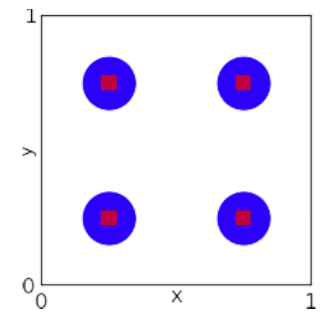

Podemos ver las cajas rojas, las cuales discretizan el espacio en donde vamos a poder encontrar las bolas rígidas. En la imagen en específico ellas se encuentran en el centro de masa de cada una. Si estas cajas fueran muy grandes podríamos perder información sobre la posición real de cada bola, lo cual nos podría llevar a conclusiones erróneas del principio de equiprobabilidad. Por esto, escogemos tamaños menores que el área de las bolas, lo cual veremos representado en el código con la variable del_xy. Vemos que en el código este es menor que sigma, que representa el tamaño de las bolas.

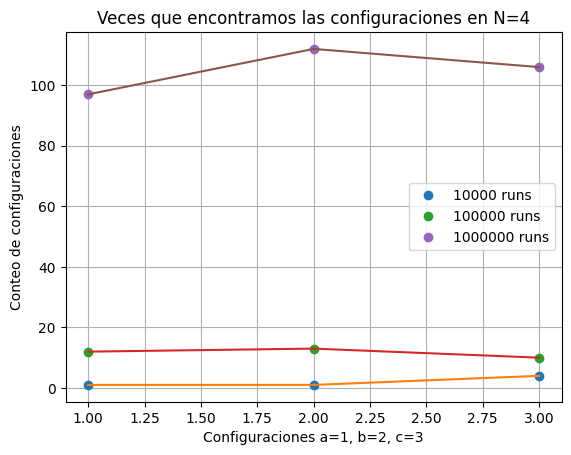

In [1]:
import random, math
import matplotlib.pyplot as plt
import numpy as np

def direct_disks_box(N, sigma):
    """
    Función que determina aleatoriamente en qué posiciones vamos a encontrar 
    las bolas en nuestra caja.
    N: Número de partículas.
    sigma: radio de las partículas
    """
    condition = False
    while condition == False:
        L = [(random.uniform(sigma, 1.0 - sigma), random.uniform(sigma, 1.0 - sigma))]
        for k in range(1, N):
            a = (random.uniform(sigma, 1.0 - sigma), random.uniform(sigma, 1.0 - sigma))
            min_dist = min(math.sqrt((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2) for b in L)
            if min_dist < 2.0 * sigma:
                condition = False
                break
            else:
                L.append(a)
                condition = True
    return L

sigma = 0.15
del_xy = 0.05
#n_runs = 10000

#Definimos las configuraciones que queremos observar
conf_a = ((0.30, 0.30), (0.30, 0.70), (0.70, 0.30), (0.70, 0.70))
conf_b = ((0.20, 0.20), (0.20, 0.80), (0.75, 0.25), (0.75, 0.75))
conf_c = ((0.30, 0.80), (0.30, 0.20), (0.70, 0.20), (0.70, 0.70))
configurations = [conf_a, conf_b, conf_c]

def f(N, n):
    """
    Función que itera varias veces la generación de ubicación de las 4 partículas
    con direct_disks_box y cuenta cada vez que una coincida con las configuraciones 
    que buscamos.
    n: Número de iteraciones.
    """
    hits = {conf_a: 0, conf_b: 0, conf_c: 0}

    for run in range(n):
        x_vec = direct_disks_box(N, sigma)
        for conf in configurations:
            condition_hit = True
            for b in conf:
                condition_b = min(max(abs(a[0] - b[0]), abs(a[1] - b[1])) for a in x_vec) < del_xy
                condition_hit *= condition_b
            if condition_hit:
                hits[conf] += 1
    return hits

nruns = [10000, 100000, 1000000]
configs=[1,2,3]

#Graficamos el modelo para cada uno de los nruns.
for i in nruns:
    Y=[]
    for j in range(len(configurations)):
        Y.append(f(4, i)[configurations[j]])
    plt.plot(configs, Y, 'o', label='{} runs'.format(i))
    plt.plot(configs, Y)

plt.title("Veces que encontramos las configuraciones en N=4")
plt.ylabel("Conteo de configuraciones")
plt.xlabel("Configuraciones a=1, b=2, c=3")
plt.grid()
plt.legend()


En dos distintos momentos de simular directamente tenemos las siguientes dos gráficas, las cuales muestran una tendencia clara a la equiprobabilidad de las configuraciones cuando tenemos muchas iteraciones.

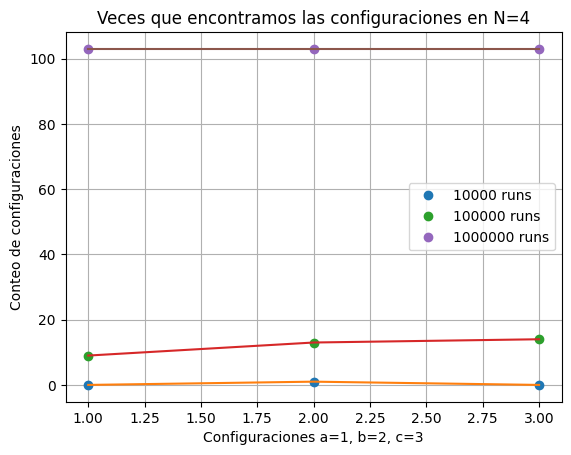

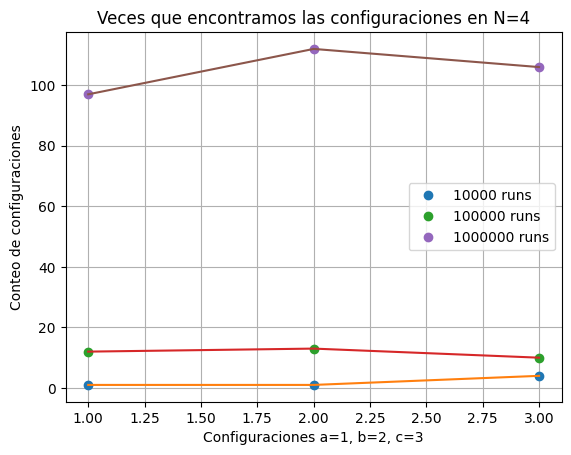

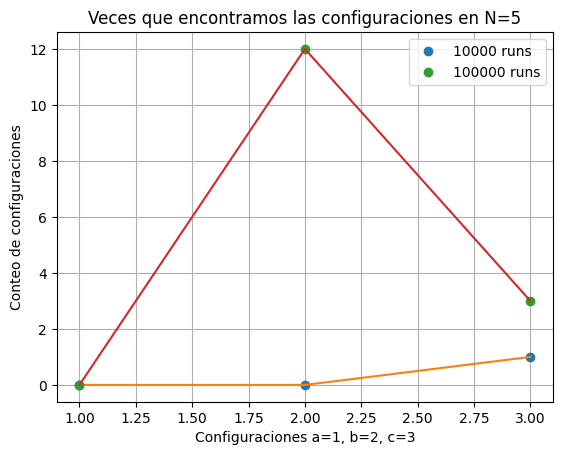

In [8]:
conf_a = ((0.30, 0.30), (0.30, 0.70), (0.70, 0.30), (0.70, 0.70), (0.50, 0.50))
conf_b = ((0.20, 0.20), (0.20, 0.80), (0.75, 0.25), (0.75, 0.75), (0.50, 0.50))
conf_c = ((0.30, 0.80), (0.30, 0.20), (0.70, 0.20), (0.70, 0.70), (0.50, 0.50))
configurations = [conf_a, conf_b, conf_c]

nruns=[10000, 100000]

for i in nruns:
    Y=[]
    for j in range(len(configurations)):
        Y.append(f(5, i)[configurations[j]])
    plt.plot(configs, Y, 'o', label='{} runs'.format(i))
    plt.plot(configs, Y)

plt.title("Veces que encontramos las configuraciones en N=5")
plt.ylabel("Conteo de configuraciones")
plt.xlabel("Configuraciones a=1, b=2, c=3")
plt.grid()
plt.legend()

En esta situación hicimos N=5. A pesar de que no logramos hacer suficientes iteraciones para ver el principio de equiprobabilidad en acción como en N=4, podemos hacer observaciones interesantes de los tiempos de cómputo que tomó.

Intentando hacer nruns como 1000, el código tomó 4 segundos. Para 10000 alrededor de 40 y para cuando hicimos las iteraciones de la forma [10000, 100000] este alcanzó cerca a 440 segundos, lo que nos muestra que el tiempo de cómputo de este código tiende a ser lineal. Teniendo en cuenta esto, se estima de que para hacer las iteraciones [10000, 100000, 1000000] debemos disponer de 74 minutos.

Para N=8:

In [10]:
#Definimos las configuraciones que queremos observar
conf_a = ((random.uniform(0, 1), random.uniform(0, 1)) for _ in range(8))
conf_b = ((random.uniform(0, 1), random.uniform(0, 1)) for _ in range(8))
conf_c = ((random.uniform(0, 1), random.uniform(0, 1)) for _ in range(8))
configurations = [conf_a, conf_b, conf_c]


nruns=[1]

for i in nruns:
    Y=[]
    for j in range(len(configurations)):
        Y.append(f(8, i)[configurations[j]])
    plt.plot(configs, Y, 'o', label='{} runs'.format(i))
    plt.plot(configs, Y)

plt.title("Veces que encontramos las configuraciones en N=8")
plt.ylabel("Conteo de configuraciones")
plt.xlabel("Configuraciones a=1, b=2, c=3")
plt.grid()
plt.legend()

KeyboardInterrupt: 

En el caso de N=8 podemos decir que el modelo es extremadamente ineficiente, si en 10 minutos no pudo converger el código para cuando nruns=1.

#### 2. Muestreo basado en Markov

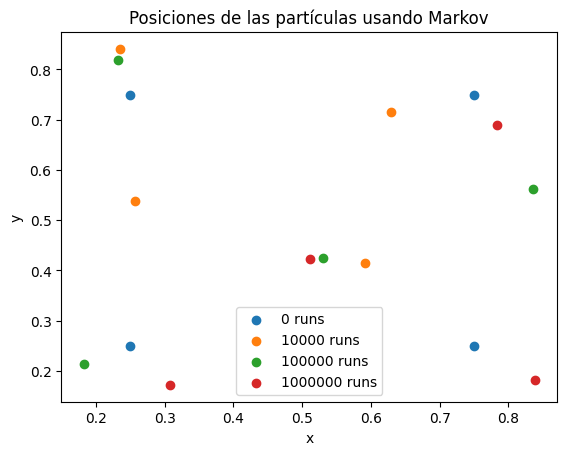

In [11]:

sigma = 0.15
sigma_sq = sigma ** 2
delta = 0.1
#n_steps = 1000
def markov(n):
    #Posicion inicial
    L = [[0.25, 0.25], [0.75, 0.25], [0.25, 0.75], [0.75, 0.75]]

    #Hacemos el cíclo que mueve uno de los componentes de L un poquito en cada iteración
    for steps in range(n):
        #Escogemos el componente a cambiar
        a = random.choice(L)
        #Cambiamos levemente este componente
        b = [a[0] + random.uniform(-delta, delta), a[1] + random.uniform(-delta, delta)]
        #Chequeamos que aún nos encontremos dentro de los parámetros del problema
        min_dist = min((b[0] - c[0])**2 + (b[1] - c[1]) **2 for c in L if c != a)
        box_cond = min(b[0], b[1]) < sigma or max(b[0], b[1]) > 1.0 - sigma
        if not (box_cond or min_dist < 4.0 * sigma ** 2):
            a[:] = b
    return L

nruns = [0,10000, 100000, 1000000]

for i in nruns:
    points = markov(i)
    x_coords = [p[0] for p in points]
    y_coords = [p[1] for p in points]
    
    # Scatter plot instead of line plot
    plt.scatter(x_coords, y_coords, label='{} runs'.format(i))

plt.title("Posiciones de las partículas usando Markov")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

Es fácil ver aquí el funcionamiento del método, pues todas las configuraciones iniciaron de la que muestra 0 iteraciones. A pesar de esto, cada configuración aparenta ser absolutamente aleatoria.

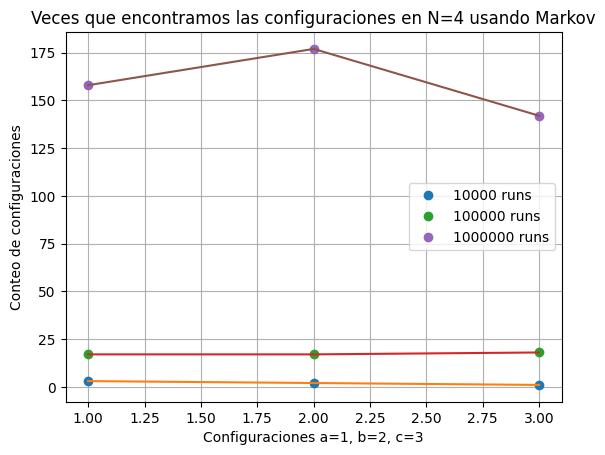

In [16]:
import random
import multiprocessing as mp
import matplotlib.pyplot as plt

sigma = 0.15
sigma_sq = sigma ** 2
delta = 0.1
del_xy = 0.05

# Define configurations as tuples (instead of lists) to use them as dictionary keys
conf_a = ((0.30, 0.30), (0.30, 0.70), (0.70, 0.30), (0.70, 0.70))
conf_b = ((0.20, 0.20), (0.20, 0.80), (0.75, 0.25), (0.75, 0.75))
conf_c = ((0.30, 0.80), (0.30, 0.20), (0.70, 0.20), (0.70, 0.70))
configurations = [conf_a, conf_b, conf_c]

def markov(n):
    """
    Función que genera las coordenadas de las partículas.
    n: Número de iteraciones.
    """
    L = [[0.25, 0.25], [0.75, 0.25], [0.25, 0.75], [0.75, 0.75]]

    for steps in range(n):
        a = random.choice(L)
        b = [a[0] + random.uniform(-delta, delta), a[1] + random.uniform(-delta, delta)]
        min_dist = min((b[0] - c[0])**2 + (b[1] - c[1]) **2 for c in L if c != a)
        box_cond = min(b[0], b[1]) < sigma or max(b[0], b[1]) > 1.0 - sigma
        if not (box_cond or min_dist < 4.0 * sigma ** 2):
            a[:] = b
    return L

def f_Markov(n):
    """
    Función que itera varias veces la generación de ubicación de las 4 partículas
    con direct_disks_box y cuenta cada vez que una coincida con las configuraciones 
    que buscamos.
    n: Número de iteraciones.
    """
    hits = {conf_a: 0, conf_b: 0, conf_c: 0}

    for run in range(n):
        x_vec = markov(100)
        for conf in configurations:
            condition_hit = True
            for b in conf:
                condition_b = min(max(abs(a[0] - b[0]), abs(a[1] - b[1])) for a in x_vec) < del_xy
                condition_hit *= condition_b
            if condition_hit:
                hits[conf] += 1
    return hits

# Run the code
nruns = [10000, 100000, 1000000]  # Number of Markov steps for each run
configs = [1, 2, 3]  # Labels for the configurations

# Plot results for each nruns
for i in nruns:
    Y = []
    for j in range(len(configurations)):
        Y.append(f_Markov(i)[configurations[j]])
    plt.plot(configs, Y, 'o', label='{} runs'.format(i))
    plt.plot(configs, Y)

plt.title("Veces que encontramos las configuraciones en N=4 usando Markov")
plt.ylabel("Conteo de configuraciones")
plt.xlabel("Configuraciones a=1, b=2, c=3")
plt.grid()
plt.legend()
plt.show()


Algo curioso que podemos ver en este método es que la cantidad de pasos que tome la cadena de Markov para navegar el área del cuadro es muy importante en estos tiempos de cómputo. En primer lugar usamos la función Markov(10), insinuando que se va a mover del estado inicial diez pasos. Esto nos da un tiempo de cómputo de 2m 24s y nos da la siguiente gráfica:

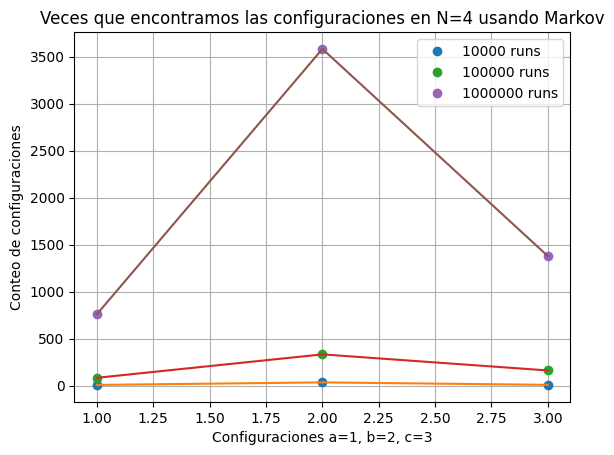

En donde podemos ver que la configuración b es mucho más probable que las otras, esto se le podría atribuír al hecho de que esta es la configuración más cercana al L en donde empezamos, lo cual la hace mucho más probable de suceder cuando estamos dando sólo 10 pasos del L inicial.

Por otro lado, cuando hacemos Markov(100), obtenemos varias cosas. En primer lugar, al igual que con el método directo, parece que el aumento de tiempo de computo tiene un comportamiento lineal frente a el número de iteraciones. 10000 son 8s, 100000 son 80s y 1000000 son 800s aproximadamente.

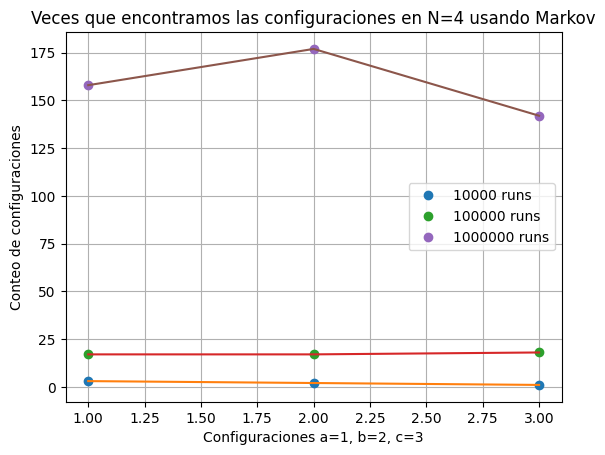

Vemos que la punta que favorece a b es mucho menos pronunciada. Esto sucede ya que la lista L tiene más oportunidad de explorar todo el respectivo espacio, lo que hace que el resultado sea finalmente mucho más cercano a una equiprobabilidad, pero con la condición de un tiempo computacional mucho más grande, de 15m 18s. Varias veces el tiempo que se obtuvo con 10 pasos, lo cual probablemente se vea exacerbado con más aumentos.

Es decir, para hacer la simulación más óptima del sistema que queremos simular, tenemos que tener en cuenta un balance entre qué tanta presicion Vs qué tanto tiempo computacional estamos dispuestos a gastar.

N=8:

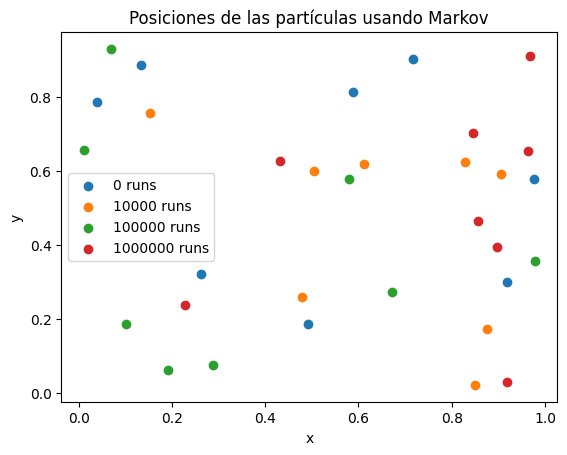

In [25]:
sigma = 0.15
sigma_sq = sigma ** 2
delta = 0.1
#n_steps = 1000
def markov8(n):
    L = [[random.uniform(0, 1), random.uniform(0, 1)] for _ in range(8)]
    for steps in range(n):
        a = random.choice(L)
        b = [a[0] + random.uniform(-delta, delta), a[1] + random.uniform(-delta, delta)]
        min_dist = min((b[0] - c[0])**2 + (b[1] - c[1]) **2 for c in L if c != a)
        box_cond = min(b[0], b[1]) < sigma or max(b[0], b[1]) > 1.0 - sigma
        if not (box_cond or min_dist < 4.0 * sigma ** 2):
            a[:] = b
    return L

nruns = [0, 10000, 100000, 1000000]

for i in nruns:
    points = markov8(i)
    x_coords = [p[0] for p in points]
    y_coords = [p[1] for p in points]
    
    # Scatter plot instead of line plot
    plt.scatter(x_coords, y_coords, label='{} runs'.format(i))

plt.title("Posiciones de las partículas usando Markov")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

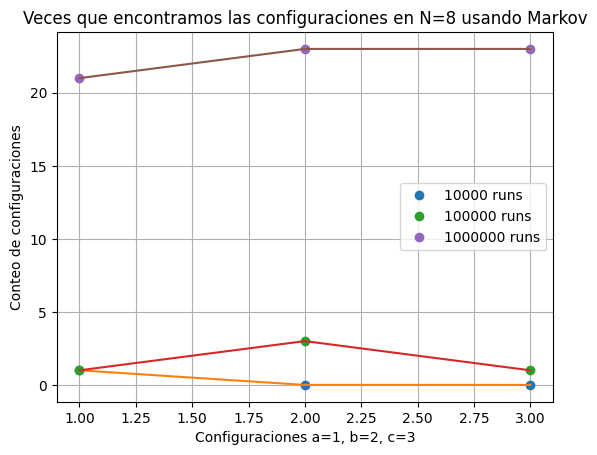

In [23]:
def f_Markov8(n):
    """
    Función que itera varias veces la generación de ubicación de las 4 partículas
    con direct_disks_box y cuenta cada vez que una coincida con las configuraciones 
    que buscamos.
    n: Número de iteraciones.
    """
    hits = {conf_a: 0, conf_b: 0, conf_c: 0}

    for run in range(n):
        x_vec = markov8(10)
        for conf in configurations:
            condition_hit = True
            for b in conf:
                condition_b = min(max(abs(a[0] - b[0]), abs(a[1] - b[1])) for a in x_vec) < del_xy
                condition_hit *= condition_b
            if condition_hit:
                hits[conf] += 1
    return hits

nruns = [10000, 100000, 1000000]
configs=[1,2,3]

#Graficamos el modelo para cada uno de los nruns.
for i in nruns:
    Y=[]
    for j in range(len(configurations)):
        Y.append(f_Markov8(i)[configurations[j]])
    plt.plot(configs, Y, 'o', label='{} runs'.format(i))
    plt.plot(configs, Y)

plt.title("Veces que encontramos las configuraciones en N=8 usando Markov")
plt.ylabel("Conteo de configuraciones")
plt.xlabel("Configuraciones a=1, b=2, c=3")
plt.grid()
plt.legend()

Curiosamente, el caso de N=8 usó menos tiempo de computo que N=4. Sería interesante el encontrar el por qué en un trabajo futuro.

En lo que podemos ver, Markov es mucho más eficiente que muestreo directo si los pasos de la función Markov(pasos) son lo suficientemente pequeños. En el caso de aumentar el número de pasos se hará cada vez más ineficente, pero mientras se mantenga un balance entre la necesidad a realismo y la necesidad de velocidad de cómputo es mucho más eficiente el usar Markov. 

Además, Markov hace una exploración del área del cuadrado que en el metodo directo existe la posibilidad de que no aparezca. Es decir, como el directo tiene números 100% aleatorios, existe la posibilidad de que todas las partículas salgan en una zona en específico o cosas por el estílo, lo cual puede causar un sesgo en los datos obtenidos. Por otro lado, con Markov tenemos unas partículas en coordenadas determinadas de la caja que la empiezan a explorar con cada caso. Esto lo podemos ver en las gráficas de las posiciones de las particulas usando Markov, podemos ver que ellas están bien distribuídas en todo el área.

#### 3. Muestreo basado en eventos

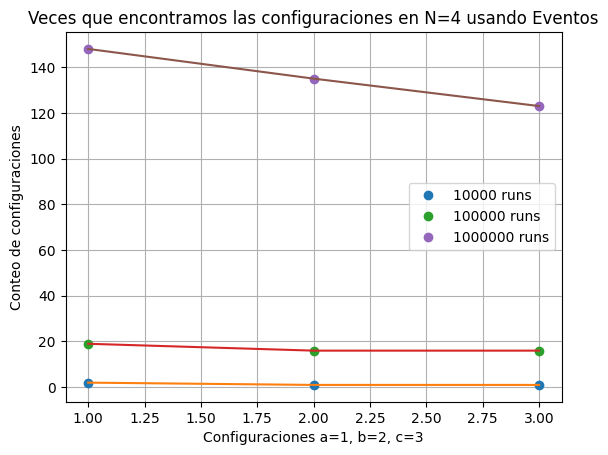

In [24]:
def wall_time(pos_a, vel_a, sigma):
    """
    Esta función calcula el tiempo hasta que la partícula a 
    colisiona contra una pared.
    pos_a: Posicion de la particula a.
    vel_a: Velocidad a la que va a.
    sigma: Radio de la particula.
    """
    if vel_a > 0.0:
        del_t = (1.0 - sigma - pos_a) / vel_a
    elif vel_a < 0.0:
        del_t = (pos_a - sigma) / abs(vel_a)
    else:
        del_t = float('inf')
    return del_t

def pair_time(pos_a, vel_a, pos_b, vel_b, sigma):
    """
    Esta función calcula el tiempo hasta que la partícula a
    colisiona con la particula b.
    pos_a: Posicion de la particula a.
    pos_b: Posicion de la particula b.
    vel_a: Velocidad a la que va a.
    vel_b: Velocidad a la que va b.
    sigma: Radio de las particulas.
    """
    del_x = [pos_b[0] - pos_a[0], pos_b[1] - pos_a[1]]
    del_x_sq = del_x[0] ** 2 + del_x[1] ** 2
    del_v = [vel_b[0] - vel_a[0], vel_b[1]- vel_a[1]]
    del_v_sq = del_v[0] ** 2 + del_v[1] ** 2
    scal = del_v[0] * del_x[0] + del_v[1] * del_x[1]
    Upsilon = scal ** 2 - del_v_sq * (del_x_sq - 4.0 * sigma ** 2)
    if Upsilon > 0.0 and scal < 0.0:
        del_t = -(scal + math.sqrt(Upsilon)) / del_v_sq
    else:
        del_t = float('inf')
    return del_t


#Definimos las configuraciones.
conf_a = ((0.30, 0.30), (0.30, 0.70), (0.70, 0.30), (0.70, 0.70))
conf_b = ((0.20, 0.20), (0.20, 0.80), (0.80, 0.25), (0.75, 0.75))
conf_c = ((0.30, 0.20), (0.30, 0.80), (0.70, 0.20), (0.70, 0.70))
configurations = [conf_a, conf_b, conf_c]
del_xy = 0.10

#Posiciones y velocidades iniciales
pos = [[0.25, 0.25], [0.75, 0.25], [0.25, 0.75], [0.75, 0.75]]
vel = [[0.21, 0.12], [0.71, 0.18], [-0.23, -0.79], [0.78, 0.1177]]

#Listas de colisiones
singles = [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0), (2, 1), (3, 0), (3, 1)]
pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
sigma = 0.10
t = 0.0
n_events = 5000000

import matplotlib.pyplot as plt

# Almacenamos las posiciones en listas
positions_x = []
positions_y = []

def eventos(n):
    global t  # Declaramos t como variable global para evitar el error
    hits = {conf_a: 0, conf_b: 0, conf_c: 0}  # Mover fuera del ciclo para acumular correctamente
    for event in range(n):
        #Listas de eventos
        wall_times = [wall_time(pos[k][l], vel[k][l], sigma) for k, l in singles]
        pair_times = [pair_time(pos[k], vel[k], pos[l], vel[l], sigma) for k, l in pairs]
        next_event = min(wall_times + pair_times)

        #Actualizamos posiciones
        t_previous = t
        for inter_times in range(int(t + 1), int(t + next_event + 1)):
            del_t = inter_times - t_previous
            for k, l in singles:
                pos[k][l] += vel[k][l] * del_t
            t_previous = inter_times
            
            # Guardamos las posiciones de las partículas en cada evento
            for k in range(len(pos)):
                positions_x.append(pos[k][0])
                positions_y.append(pos[k][1]) 
            
            #Comparamos con las configuraciones
            for conf in configurations:
                condition_hit = True
                for b in conf:
                    condition_b = min(max(abs(a[0] - b[0]), abs(a[1] - b[1])) for a in pos) < del_xy
                    condition_hit *= condition_b
                if condition_hit:
                    hits[conf] += 1
        
        t += next_event
        del_t = t - t_previous
        for k, l in singles:
            pos[k][l] += vel[k][l] * del_t
        
        #Vemos si el evento es una colisión con una pared o con otra partícula
        if min(wall_times) < min(pair_times):
            collision_disk, direction = singles[wall_times.index(next_event)]
            vel[collision_disk][direction] *= -1.0
        else:
            a, b = pairs[pair_times.index(next_event)]
            del_x = [pos[b][0] - pos[a][0], pos[b][1] - pos[a][1]]
            abs_x = math.sqrt(del_x[0] ** 2 + del_x[1] ** 2)
            e_perp = [c / abs_x for c in del_x]
            del_v = [vel[b][0] - vel[a][0], vel[b][1] - vel[a][1]]
            scal = del_v[0] * e_perp[0] + del_v[1] * e_perp[1]
            for k in range(2):
                vel[a][k] += e_perp[k] * scal
                vel[b][k] -= e_perp[k] * scal

    return hits

        
nruns = [10000, 100000, 1000000]
configs=[1,2,3]

#Graficamos el modelo para cada uno de los nruns.
for i in nruns:
    Y=[]
    for j in range(len(configurations)):
        Y.append(eventos(i)[configurations[j]])
    plt.plot(configs, Y, 'o', label='{} runs'.format(i))
    plt.plot(configs, Y)

plt.title("Veces que encontramos las configuraciones en N=4 usando Eventos")
plt.ylabel("Conteo de configuraciones")
plt.xlabel("Configuraciones a=1, b=2, c=3")
plt.grid() 
plt.legend()


En el caso del muestreo basado en eventos podemos ver claramente que las configuraciones están intentando aumentar en la misma medida. En teoría, si las iteraciones -> inf, entonces obtendríamos una igualdad perfecta entre las configuraciones. Se cumple el principio de equiprobabilidad.

Cabe resaltar que este método es extremadamente eficiente. En donde muestreo directo se demoraba aprox 5 mins, Markov 15 mins (o 2 en N=2), el muestreo basado en eventos se demora 48s, lo que lo convertiría el más eficiente de todos los métodos usados.

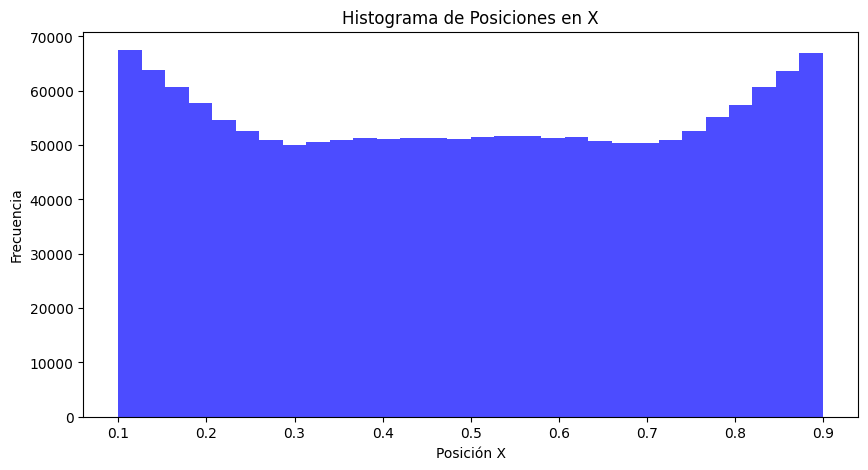

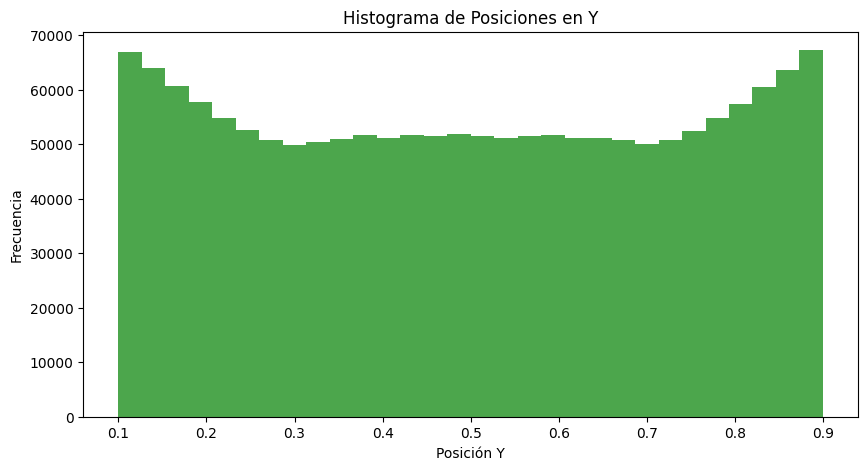

In [26]:
# Ejecutamos la simulación
eventos(10000)  

# Generarmos un histograma de posiciones x
plt.figure(figsize=(10, 5))
plt.hist(positions_x, bins=30, color='blue', alpha=0.7)
plt.title('Histograma de Posiciones en X')
plt.xlabel('Posición X')
plt.ylabel('Frecuencia')
plt.show()

# Generamos un histograma de posiciones y
plt.figure(figsize=(10, 5))
plt.hist(positions_y, bins=30, color='green', alpha=0.7)
plt.title('Histograma de Posiciones en Y')
plt.xlabel('Posición Y')
plt.ylabel('Frecuencia')
plt.show()


En este caso podemos ver claramente que no todas las posiciones en la caja son igualmente probables. Esto se debe a las colisiones de las partículas con las paredes de la caja, lo cual causa que podamos encontrar estas partículas en estas posiciones más frecuentemente.

Por otro lado, podemos ver que en el centro de la caja las posiciones tienden a los mismos valores de probabilidad.

#### 4. Histograma de posiciones



(array([57579., 55448., 54820., 53110., 52247., 51065., 50384., 49246.,
        47669., 46856., 46156., 44809., 43795., 43023., 41992., 41057.,
        40240., 39791., 39027., 38351., 37563., 37126., 36450., 35762.,
        35294., 34836., 34456., 33937., 33688., 33578., 33248., 33511.,
        33881., 34284., 34750., 34771., 35303., 35453., 35722., 35403.,
        35804., 35788., 36286., 36394., 36084., 36328., 36692., 36611.,
        36597., 36711., 36764., 36551., 36665., 36551., 36694., 36374.,
        36646., 36116., 36161., 35961., 35744., 35520., 35634., 34776.,
        34969., 34223., 34380., 34226., 33657., 33832., 33297., 33892.,
        34239., 34305., 34934., 35452., 35815., 36178., 36988., 37627.,
        38367., 38585., 39616., 40658., 41286., 42238., 43130., 44037.,
        45280., 45859., 46674., 47802., 49095., 49880., 51187., 52111.,
        53245., 54540., 55849., 57414.]),
 array([0.11970008, 0.12730608, 0.13491208, 0.14251807, 0.15012407,
        0.15773007, 0.1653

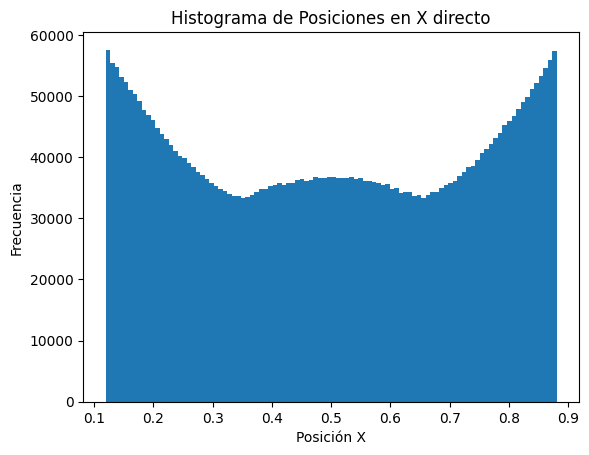

In [34]:
def direct_disks_box(N, sigma):
    overlap = True
    while overlap == True:
        L = [(random.uniform(sigma, 1.0 - sigma), random.uniform(sigma, 1.0 - sigma))]
        for k in range(1, N):
            a = (random.uniform(sigma, 1.0 - sigma), random.uniform(sigma, 1.0 - sigma))
            min_dist_sq = min(((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2) for b in L)
            if min_dist_sq < 4.0 * sigma ** 2:
                overlap = True
                break
            else:
                L.append(a)
                overlap = False
    return L

N=4
sigma = 0.1197
n_runs = 1000000
histo_data = []
for run in range(n_runs):
    pos = direct_disks_box(N, sigma)
    for k in range(N):
        histo_data.append(pos[k][0])

plt.title('Histograma de Posiciones en X directo')
plt.xlabel('Posición X')
plt.ylabel('Frecuencia')
plt.hist(histo_data, bins=100)

(array([ 5650.,  6012.,  6367.,  6848., 12276., 12211., 12372., 12321.,
        12256., 12260., 12388., 12267., 12160., 12214., 12480., 12378.,
        12850., 35283., 12571., 12380., 11910., 11663., 11326., 11058.,
        10813., 10575., 10157.,  9835.,  9581.,  8927.,  6465.,  5037.,
         4709.,  4398.,  3905.,  3606.,  3222.,  2831.,  2558.,  2266.,
         1812.,  1497.,  1226.,   952.,   873.,   714.,   640.,   631.,
          603.,   617.,   614.,   583.,   613.,   679.,   734.,   843.,
          924.,  1264.,  1595.,  1892.,  2213.,  2534.,  2953.,  3257.,
         3623.,  3952.,  4337.,  4632.,  5066.,  6372.,  8981.,  9473.,
         9708., 10273., 10389., 10888., 11101., 11459., 11707., 12013.,
        12355., 12535., 35659., 12689., 12488., 12388., 12232., 12041.,
        12189., 12265., 12034., 12126., 12372., 12242., 12276., 12185.,
         6949.,  6512.,  6077.,  5763.]),
 array([0.11970042, 0.1273064 , 0.13491239, 0.14251838, 0.15012437,
        0.15773036, 0.1653

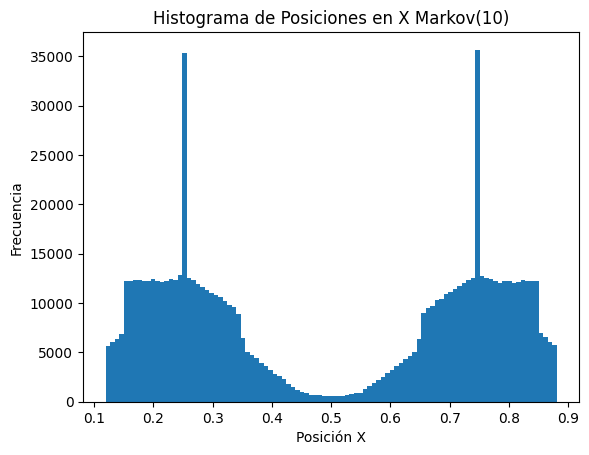

In [35]:
def markov(n):
    L = [[0.25, 0.25], [0.75, 0.25], [0.25, 0.75], [0.75, 0.75]]
    for steps in range(n):
        a = random.choice(L)
        b = [a[0] + random.uniform(-delta, delta), a[1] + random.uniform(-delta, delta)]
        min_dist = min((b[0] - c[0])**2 + (b[1] - c[1]) **2 for c in L if c != a)
        box_cond = min(b[0], b[1]) < sigma or max(b[0], b[1]) > 1.0 - sigma
        if not (box_cond or min_dist < 4.0 * sigma ** 2):
            a[:] = b
    return L


N=4
sigma = 0.1197
n_runs = 200000
histo_data = []
for run in range(n_runs):
    pos = markov(10)
    for k in range(N):
        histo_data.append(pos[k][0])
plt.title('Histograma de Posiciones en X Markov(10)')
plt.xlabel('Posición X')
plt.ylabel('Frecuencia')
plt.hist(histo_data, bins=100)

Aquí se ha usado la función Markov(10), lo que muestra claramente de lo que se hablaba anteriormente de que con pocos pasos para moverse las partículas van a tender a estar en un área muy limitada, que sería en los alrededores de las coordenadas iniciales de L.

(array([1157., 1083., 1098., 1045., 1069., 1010., 1006.,  995.,  962.,
         921.,  930.,  954.,  919.,  886.,  863.,  868.,  879.,  827.,
         802.,  809.,  814.,  760.,  769.,  800.,  714.,  702.,  697.,
         765.,  731.,  682.,  716.,  685.,  692.,  671.,  674.,  700.,
         658.,  667.,  686.,  678.,  649.,  617.,  693.,  647.,  684.,
         661.,  699.,  648.,  652.,  659.,  653.,  634.,  689.,  673.,
         663.,  675.,  645.,  629.,  703.,  619.,  661.,  685.,  661.,
         665.,  683.,  645.,  690.,  680.,  655.,  739.,  734.,  692.,
         702.,  746.,  753.,  777.,  723.,  746.,  796.,  837.,  829.,
         819.,  848.,  858.,  842.,  904.,  897.,  956.,  945.,  968.,
         992.,  927., 1032.,  996., 1010.,  994., 1068., 1127., 1083.,
        1099.]),
 array([0.11970046, 0.12730643, 0.13491239, 0.14251835, 0.15012431,
        0.15773028, 0.16533624, 0.1729422 , 0.18054816, 0.18815412,
        0.19576009, 0.20336605, 0.21097201, 0.21857797, 0.22618394

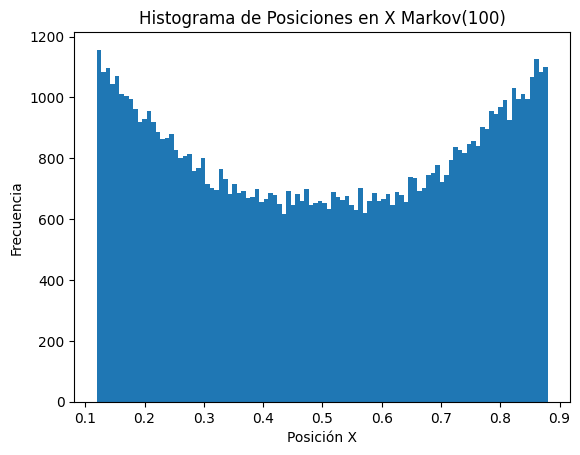

In [36]:
N=4
sigma = 0.1197
n_runs = 20000
histo_data = []
for run in range(n_runs):
    pos = markov(100)
    for k in range(N):
        histo_data.append(pos[k][0])
plt.title('Histograma de Posiciones en X Markov(100)')
plt.xlabel('Posición X')
plt.ylabel('Frecuencia')
plt.hist(histo_data, bins=100)

En el caso de que usemos Markov(100), a pesar de que la anterios gráfica tenga menos cantidad de iteraciones que todas las otras, podemos ver claramente que la distibución de probabilidades se asemeja mucho más a las de los otros métodos. Esto se puede atribuír a que 100 pasos se puede considerar como suficiente para recorrer todo el espacio.

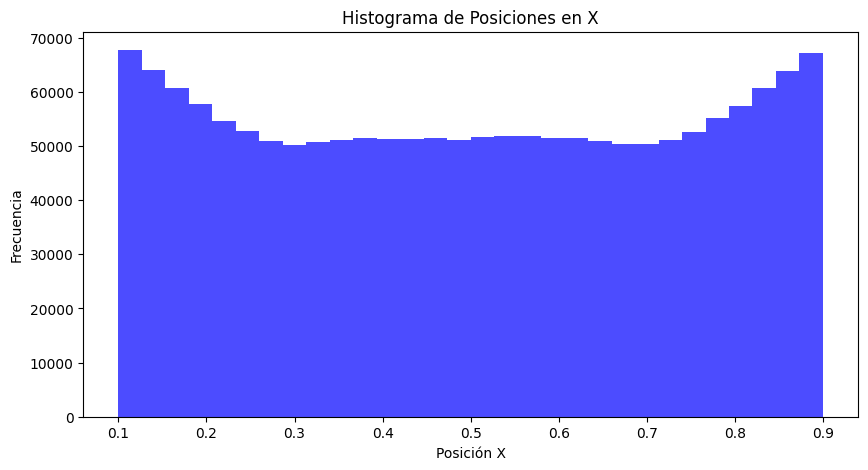

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(positions_x, bins=30, color='blue', alpha=0.7)
plt.title('Histograma de Posiciones en X')
plt.xlabel('Posición X')
plt.ylabel('Frecuencia')
plt.show()

Podemos ver que en los tres métodos de muestreo se encuentra una tendencia a las posiciones cerca a las paredes. Esto se debe al radio de las partículas, pues las partículas no se pueden superponer. Esto inidca a un tipo de repulsión efectiva entre las partículas y también una tendencia a habitar las paredes donde hay menos de densidad de partículas alrededor.

#### 4. Animación

Producing animation.gif using ImageMagick...


4

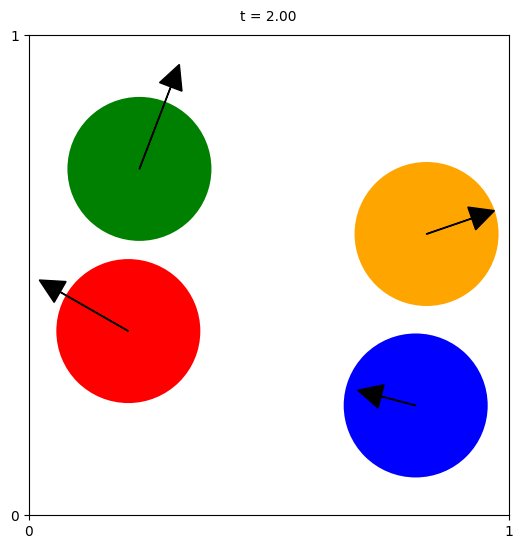

In [19]:
import os, math

output_dir = "event_disks_box_movie"
colors = ['r', 'b', 'g', 'orange']

def wall_time(pos_a, vel_a, sigma):
    if vel_a > 0.0:
        del_t = (1.0 - sigma - pos_a) / vel_a
    elif vel_a < 0.0:
        del_t = (pos_a - sigma) / abs(vel_a)
    else:
        del_t = float('inf')
    return del_t

def pair_time(pos_a, vel_a, pos_b, vel_b, sigma):
    del_x = [pos_b[0] - pos_a[0], pos_b[1] - pos_a[1]]
    del_x_sq = del_x[0] ** 2 + del_x[1] ** 2
    del_v = [vel_b[0] - vel_a[0], vel_b[1]- vel_a[1]]
    del_v_sq = del_v[0] ** 2 + del_v[1] ** 2
    scal = del_v[0] * del_x[0] + del_v[1] * del_x[1]
    Upsilon = scal ** 2 - del_v_sq * (del_x_sq - 4.0 * sigma ** 2)
    if Upsilon > 0.0 and scal < 0.0:
        del_t = -(scal + math.sqrt(Upsilon)) / del_v_sq
    else:
        del_t = float('inf')
    return del_t

def min_arg(l):
    return min(zip(l, range(len(l))))

def compute_next_event(pos, vel):
    wall_times = [wall_time(pos[k][l], vel[k][l], sigma) for k, l in singles]
    pair_times = [pair_time(pos[k], vel[k], pos[l], vel[l], sigma) for k, l in pairs]
    return min_arg(wall_times + pair_times)

def compute_new_velocities(pos, vel, next_event_arg):
    if next_event_arg < len(singles):
        collision_disk, direction = singles[next_event_arg]
        vel[collision_disk][direction] *= -1.0
    else:
        a, b = pairs[next_event_arg - len(singles)]
        del_x = [pos[b][0] - pos[a][0], pos[b][1] - pos[a][1]]
        abs_x = math.sqrt(del_x[0] ** 2 + del_x[1] ** 2)
        e_perp = [c/abs_x for c in del_x]
        del_v = [vel[b][0] - vel[a][0], vel[b][1] - vel[a][1]]
        scal = del_v[0] * e_perp[0] + del_v[1] * e_perp[1]
        for k in range(2):
            vel[a][k] += e_perp[k] * scal
            vel[b][k] -= e_perp[k] * scal

plt.subplots_adjust(left=0.10, right=0.90, top=0.90, bottom=0.10)
plt.gcf().set_size_inches(6, 6)

img = 0

if not os.path.exists(output_dir): 
    os.makedirs(output_dir)

def snapshot(t, pos, vel, colors, arrow_scale=.2):
    global img
    plt.cla()
    plt.axis([0, 1, 0, 1])
    plt.setp(plt.gca(), xticks=[0, 1], yticks=[0, 1])
    for (x, y), (dx, dy), c in zip(pos, vel, colors):
        dx *= arrow_scale
        dy *= arrow_scale
        circle = plt.Circle((x, y), radius=sigma, fc=c)
        plt.gca().add_patch(circle)
        plt.arrow(x, y, dx, dy, fc="k", ec="k", head_width=0.05, head_length=0.05)
    plt.text(.5, 1.03, 't = %.2f' % t, ha='center')
    plt.savefig(os.path.join(output_dir, '%04i.png' % img))
    img += 1

pos = [[0.25, 0.25], [0.75, 0.25], [0.25, 0.75], [0.75, 0.75]]
vel = [[0.21, 0.12], [0.71, 0.18], [-0.23, -0.79], [0.78, 0.1177]]
singles = [(0, 0), (0, 1), (1, 0), (1, 1), (2, 0), (2, 1), (3, 0), (3, 1)]
pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
sigma = 0.15
t = 0.0
dt = 0.02
n_steps = 100

next_event, next_event_arg = compute_next_event(pos, vel)
snapshot(t, pos, vel, colors)

for step in range(n_steps):
    if dt:
        next_t = t + dt
    else:
        next_t = t + next_event

    while t + next_event <= next_t:
        t += next_event
        for k, l in singles:
            pos[k][l] += vel[k][l] * next_event
        compute_new_velocities(pos, vel, next_event_arg)
        next_event, next_event_arg = compute_next_event(pos, vel)
    remain_t = next_t - t
    for k, l in singles:
        pos[k][l] += vel[k][l] * remain_t
    t += remain_t
    next_event -= remain_t

    snapshot(t, pos, vel, colors)

print('Producing animation.gif using ImageMagick...')
os.system("convert -delay 1 -dispose Background +page " + str(output_dir) +
          "/*.png -loop 0 " + str(output_dir) + "/animation.gif")




### Conclusiones

Este estudio permitió comparar tres distintos métodos de muestreo con los cuales podemos evaluar la equiprobabilidad en un sistema simple de discos. 

Con respecto a la eficiencia computacional, podemos decir que hay unos métodos mucho más efectivos que los otros, pero hay que tener en cuenta algunos aspectos que pueden causar sesgos.

Con respecto a la equiprobabilidad de las configuraciones, pudimos ver que algunos de los métodos tienen en cuenta aspectos del comportamiento de las partículas, lo que permite simular configuraciones más realistas. El realizar esto nos muestra que, cuando estamos hablando de la probabilidad de las posiciones en las que encontramos las partículas, ellas no serán exactamente iguales. Esto es verdad a pesar de que las configuraciones sí tienden a la misma probabilidad entre ellas.

### Bibliografía

[1] Brownlee, J. (2019, September 24). A gentle introduction to Monte Carlo sampling for probability. MachineLearningMastery.com. https://machinelearningmastery.com/monte-carlo-sampling-for-probability/

[2] Ibm. (2024, August 9). What is Monte Carlo Simulation?. IBM. https://www.ibm.com/topics/monte-carlo-simulation 

[3] Markov chain Monte Carlo. Columbia University Mailman School of Public Health. (2023, March 13). https://www.publichealth.columbia.edu/research/population-health-methods/markov-chain-monte-carlo 

[4] (2005). Event-Driven Molecular Dynamics. In: Computational Granular Dynamics. Springer, Berlin, Heidelberg. https://doi-org.udea.lookproxy.com/10.1007/3-540-27720-X_3